In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [50]:
dataset_path = os.path.realpath(
    os.path.join(
        os.getcwd(),
        "..",
        "Radar",
        "C3"
    )
)
test_f_path = os.path.realpath(
    os.path.join(
        dataset_path,
        "U03",
        "E01",
        "01",
        "2.pkl",
    )
)
test_data = pd.read_pickle(test_f_path)
test_data

[array([[ 1.75302405e+09,  2.20507812e+00,  1.42578125e-01,
         -6.26953125e-01,  1.04139271e+01]]),
 array([[ 1.75302405e+09,  2.18164062e+00,  2.10937500e-01,
         -5.09765625e-01,  1.38021126e+01],
        [ 1.75302405e+09,  2.31054688e+00,  7.22656250e-02,
         -3.86718750e-01,  1.07918129e+01]]),
 array([[ 1.75302405e+09,  1.76367188e+00, -1.11328125e-01,
         -2.22656250e-01,  1.20411997e+01],
        [ 1.75302405e+09,  2.33203125e+00, -0.00000000e+00,
         -2.36328125e-01,  1.25527248e+01],
        [ 1.75302405e+09,  2.24218750e+00,  1.40625000e-01,
         -9.76562500e-02,  1.96848297e+01]]),
 array([[ 1.75302405e+09,  1.75390625e+00, -1.66015625e-01,
         -2.61718750e-01,  1.56820173e+01],
        [ 1.75302405e+09,  2.20117188e+00, -6.83593750e-02,
          5.85937500e-02,  1.97772369e+01],
        [ 1.75302405e+09,  2.34179688e+00, -0.00000000e+00,
         -8.78906250e-02,  1.56820173e+01],
        [ 1.75302405e+09,  2.07226562e+00, -0.00000000e+00

In [51]:
len(test_data)

169

In [52]:
test_data[0]

array([[ 1.75302405e+09,  2.20507812e+00,  1.42578125e-01,
        -6.26953125e-01,  1.04139271e+01]])

In [53]:
test_data[1]

array([[ 1.75302405e+09,  2.18164062e+00,  2.10937500e-01,
        -5.09765625e-01,  1.38021126e+01],
       [ 1.75302405e+09,  2.31054688e+00,  7.22656250e-02,
        -3.86718750e-01,  1.07918129e+01]])

In [54]:
for i in range(0, int(len(test_data)/12)):
    print(test_data[i].shape)

(1, 5)
(2, 5)
(3, 5)
(5, 5)
(4, 5)
(2, 5)
(1, 5)
(1, 5)
(1, 5)
(1, 5)
(3, 5)
(3, 5)
(2, 5)
(2, 5)


In [55]:
emotions = {
    "E01": "focus",
    "E02": "distraction",
    "E03": "stress",
    "E04": "relaxation",
    "E05": "depression",
    "E06": "excitement"
}

In [56]:
ceiling_radars= list(range(0, 5))
ground_radars = list(range(5, 13))

In [74]:
X = []
RADAR = []
y = []

for u in os.listdir(dataset_path):
    if not u.startswith("U"):
        continue
    print(f"For user {u}:")
    for e in os.listdir(os.path.join(dataset_path, u)):
        if not e.startswith("E"):
            continue
        
        print(f"\tFor emotion {emotions[e]}:")
        emotion_label = emotions[e]
        radar_files = os.listdir(os.path.join(dataset_path, u, e, "01"))
        
        sequences_size = []
        for f in radar_files:
            file_path = os.path.join(dataset_path, u, e, "01", f)
            data = pd.read_pickle(file_path)
            
            sequence = np.vstack(data)
            sequences_size.append(sequence.shape[0])
            X.append(sequence)
            RADAR.append(("CEILING" if int(f[0]) < 5 else "GROUND") + " " + f[0])
            y.append(emotion_label)
        
        print(f"\t\t Sequences length: {sequences_size} samples")

For user U07:
	For emotion stress:
		 Sequences length: [524, 379, 610, 886, 360, 513, 675, 1279, 290, 703, 311, 880, 783] samples
	For emotion relaxation:
		 Sequences length: [160, 73, 321, 552, 223, 326, 301, 489, 114, 348, 188, 385, 357] samples
	For emotion depression:
		 Sequences length: [254, 59, 214, 300, 119, 146, 194, 410, 13, 179, 17, 123, 75] samples
	For emotion distraction:
		 Sequences length: [198, 155, 521, 609, 232, 544, 605, 868, 282, 610, 347, 638, 737] samples
	For emotion focus:
		 Sequences length: [280, 121, 521, 525, 281, 367, 332, 594, 212, 500, 432, 393, 378] samples
	For emotion excitement:
		 Sequences length: [483, 32, 195, 323, 96, 156, 109, 149, 2, 103, 4, 153] samples
For user U38:
	For emotion stress:
		 Sequences length: [291, 121, 450, 470, 299, 325, 425, 463, 108, 547, 138, 730, 389] samples
	For emotion relaxation:
		 Sequences length: [48, 50, 156, 205, 59, 127, 130, 174, 33, 209, 63, 215, 72] samples
	For emotion depression:
		 Sequences length:

Every element of X is the sequence captured by a specific radar for a specific emotion of the same index.

In [58]:
print(X[5][:3])
print(RADAR[5])
print(y[5])

[[ 1.75292708e+09  1.38476562e+00 -2.50195312e+00  0.00000000e+00
   1.11394339e+01]
 [ 1.75292708e+09  3.90429688e+00 -4.92187500e-01  1.30859375e-01
   1.11394339e+01]
 [ 1.75292708e+09  3.83593750e+00 -2.40234375e-01 -2.53906250e-02
   1.14612808e+01]]
GROUND 6
stress


In [70]:
sample_idx = 5
seq = X[sample_idx]
label = y[sample_idx]

print(f"Sample {sample_idx} - Radar: {RADAR[sample_idx]}, Emotion: {label}")
print(seq[0][1], seq[1][1], seq[2][1], seq[3][1], seq[4][1]) 

# plt.figure(figsize=(16, 8))
# plt.plot(seq[:, 0] - seq[0, 0], seq[:, 1], label="RSSI")
# plt.plot(seq[:, 0] - seq[0, 0], seq[:, 2], label="PhaseAngle")
# plt.plot(seq[:, 0] - seq[0, 0], seq[:, 3], label="DopplerFrequency")

# plt.xlabel("Time (s)")
# plt.ylabel("Sensor Value")
# plt.title(f"Radar {RADAR[sample_idx]} - Emotion: {label}")
# plt.legend()
# plt.show()

Sample 5 - Radar: GROUND 6, Emotion: stress
1.384765625 3.904296875 3.8359375 4.0625 3.8828125


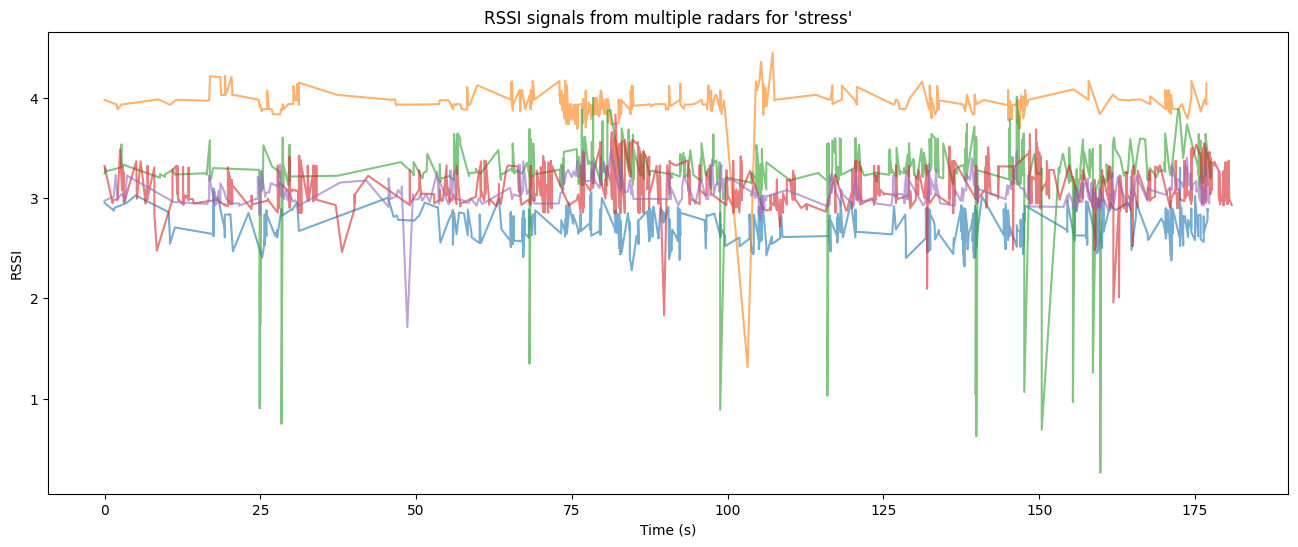

In [60]:
user_emotion_idx = [i for i, lab in enumerate(y) if lab=="stress"][:5]
plt.figure(figsize=(16,6))

for i in user_emotion_idx:
    seq = X[i]
    plt.plot(seq[:,0] - seq[0,0], seq[:,1], alpha=0.6)

plt.xlabel("Time (s)")
plt.ylabel("RSSI")
plt.title("RSSI signals from multiple radars for 'stress'")
plt.show()

<Figure size 1400x600 with 0 Axes>

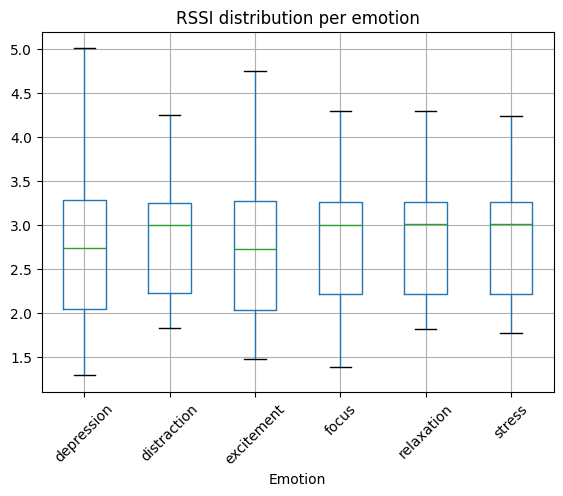

In [61]:
feature_means = []
for seq, label in zip(X, y):
    mean_vals = seq[:,1:].mean(axis=0)
    feature_means.append([label] + mean_vals.tolist())

df_features = pd.DataFrame(feature_means, columns=["Emotion", "RSSI", "PhaseAngle", "DopplerFrequency", "Frequency"])

plt.figure(figsize=(14,6))
df_features.boxplot(column="RSSI", by="Emotion")
plt.title("RSSI distribution per emotion")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()